In [1]:
!pip install -q "transformers>=4.37.0" accelerate sentencepiece protobuf flash-attn --no-build-isolation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 59.8 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done


In [2]:
import transformers
print(f"Transformers version: {transformers.__version__}")

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Transformers version: 5.2.0
PyTorch: 2.9.0+cu126
CUDA available: True
GPU: NVIDIA H100 80GB HBM3


In [3]:
import os, re, time, json
import pandas as pd
import torch
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer
import matplotlib.pyplot as plt
import seaborn as sns

# Config
MODEL_NAME     = "meta-llama/Meta-Llama-3.1-8B-Instruct"
MAX_SAMPLES    = 500
MAX_NEW_TOKENS = 1024
EVAL_BATCH_SIZE = 64
DEVICE         = "cuda" if torch.cuda.is_available() else "cpu"
OUTPUT_DIR       = "/kaggle/working/llama3.1_math500"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Device: {DEVICE}")
print(f"Model : {MODEL_NAME}")

Device: cuda
Model : meta-llama/Meta-Llama-3.1-8B-Instruct


In [4]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")
login(token=hf_token)
print("Logged in to Hugging Face.")

Logged in to Hugging Face.


In [5]:
import glob

matches = glob.glob('/kaggle/input/**/math_500_test.csv', recursive=True)
DATA_PATH = matches[0] if matches else '/kaggle/input/math-500/math_500_test.csv'
print(f"Loading from: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)[['Question', 'Answer']].head(MAX_SAMPLES).reset_index(drop=True)
print(f"Loaded {len(df)} questions")

Loading from: /kaggle/input/datasets/vybhavchaturvedi/math-500/math_500_test.csv
Loaded 500 questions


In [6]:
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True, padding_side='left')

#VYBHAV - Llama 3 does not have a dedicated pad token — use eos token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

print("Loading model in bfloat16 (H100 has 80GB, no quantization needed)...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="flash_attention_2",
)
model.eval()
model = torch.compile(model, mode="reduce-overhead")
print(f"Model on: {next(model.parameters()).device}")

Loading tokenizer...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

Model on: cuda:0


In [7]:
def extract_boxed(text):
    text = str(text)
    idx = text.find('\\boxed{')
    if idx != -1:
        depth, start, end = 1, idx + 7, idx + 7
        while end < len(text) and depth > 0:
            if text[end] == '{': depth += 1
            elif text[end] == '}': depth -= 1
            end += 1
        if depth == 0:
            return text[start:end-1]
    match = re.search(r'final answer is[:\s]*([^\n.]+)', text, re.IGNORECASE)
    return match.group(1).strip() if match else text.strip()

def normalize(ans):
    ans = str(ans).strip()
    ans = re.sub(r'\\text\{([^}]*)\}', r'\1', ans)
    ans = re.sub(r'\\frac\{([^}]*)\}\{([^}]*)\}', r'(\1)/(\2)', ans)
    return re.sub(r'[^\w.+\-/]', '', ans.lower())

def is_correct(pred, gt):
    p, g = normalize(extract_boxed(pred)), normalize(extract_boxed(gt))
    if p == g: return True
    try:
        return abs(float(p.replace('^','**')) - float(g.replace('^','**'))) < 1e-6
    except:
        return False

In [8]:
# Prompts taken from the original TokenSkip research paper
PROMPTS = {
    "Original":    "Solve the following math problem step by step. Put your final answer within \\boxed{{}}.\n\nProblem: {question}\n\nSolution:",
    "BeConcise":   "Be concise. Solve the following math problem step by step. Put your final answer within \\boxed{{}}.\n\nProblem: {question}\n\nSolution:",
    "OnlyNumbers": "Only use numbers or equations. Solve the following math problem step by step. Put your final answer within \\boxed{{}}.\n\nProblem: {question}\n\nSolution:",
    "AbbreWords":  "Abbreviate words as much as possible. Solve the following math problem step by step. Put your final answer within \\boxed{{}}.\n\nProblem: {question}\n\nSolution:",
}

def make_prompt(question, method):
    prompt   = PROMPTS[method].format(question=question)
    messages = [{"role": "user", "content": prompt}]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

In [9]:
def evaluate_batched(df, method="Original", max_new_tokens=MAX_NEW_TOKENS, original_avg_tokens=None):
    all_responses    = []
    all_token_counts = []
    start_time       = time.time()

    prompts_indexed = [(i, make_prompt(row['Question'], method)) for i, row in df.iterrows()]
    prompts_indexed.sort(key=lambda x: len(x[1]))
    sorted_indices = [i for i, _ in prompts_indexed]
    prompts        = [p for _, p in prompts_indexed]

    for batch_start in tqdm(range(0, len(prompts), EVAL_BATCH_SIZE),
                             desc=f"{method} (bs={EVAL_BATCH_SIZE})"):
        batch_prompts = prompts[batch_start:batch_start + EVAL_BATCH_SIZE]

        inputs = tokenizer(
            batch_prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=2048
        ).to(DEVICE)

        input_len = inputs['input_ids'].shape[1]

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )

        generated   = outputs[:, input_len:]
        token_counts = (generated != tokenizer.pad_token_id).sum(dim=1).tolist()
        all_token_counts.extend(token_counts)

        responses = tokenizer.batch_decode(generated, skip_special_tokens=True)
        all_responses.extend(responses)

        del outputs, inputs, generated
        torch.cuda.empty_cache()

    #VYBHAV - Restore original row order so responses align with df
    reordered_responses    = [None] * len(df)
    reordered_token_counts = [None] * len(df)
    for sorted_pos, orig_idx in enumerate(sorted_indices):
        reordered_responses[orig_idx]    = all_responses[sorted_pos]
        reordered_token_counts[orig_idx] = all_token_counts[sorted_pos]

    elapsed    = time.time() - start_time
    correct    = sum(is_correct(r, g) for r, g in zip(reordered_responses, df['Answer']))
    avg_tokens = sum(reordered_token_counts) / len(df)

    return {
        'Method':     method,
        'Accuracy':   round(100 * correct / len(df), 2),
        'Avg Tokens': round(avg_tokens, 2),
        'Latency(s)': round(elapsed / len(df), 3),
        'Act Ratio':  round(avg_tokens / original_avg_tokens if original_avg_tokens else 1.0, 3),
        'Correct':    correct,
        'Total':      len(df),
    }, reordered_responses, reordered_token_counts

In [10]:
all_results           = []
all_responses_dict    = {}
all_token_counts_dict = {}
checkpoint_path      = f"{OUTPUT_DIR}/checkpoint.json"

if os.path.exists(checkpoint_path):
    with open(checkpoint_path) as f:
        checkpoint = json.load(f)
    all_results       = checkpoint.get('results', [])
    completed_methods = {r['Method'] for r in all_results}
    print(f"Resuming: {completed_methods} already done")
else:
    completed_methods = set()

eval_start = time.time()

for method in ["Original", "BeConcise", "OnlyNumbers", "AbbreWords"]:
    if method in completed_methods:
        print(f"Skipping {method} (already done)")
        continue

    print(f"\n{'='*60}\nEvaluating: {method}\n{'='*60}")
    orig_tokens = next((r['Avg Tokens'] for r in all_results if r['Method'] == 'Original'), None)

    result, responses, token_counts = evaluate_batched(df, method=method, original_avg_tokens=orig_tokens)
    all_results.append(result)
    all_responses_dict[method]    = responses
    all_token_counts_dict[method] = token_counts
    print(f"{method}: {result['Accuracy']:.1f}% acc | {result['Avg Tokens']:.1f} tokens | {result['Latency(s)']:.2f}s/sample")

    with open(checkpoint_path, 'w') as f:
        json.dump({'results': all_results}, f)

orig_tokens = next(r['Avg Tokens'] for r in all_results if r['Method'] == 'Original')

for ratio in [0.9, 0.8, 0.7, 0.6, 0.5]:
    method_key = f"Truncation_{ratio}"
    if method_key in completed_methods:
        print(f"Skipping {method_key} (already done)")
        continue

    print(f"\n{'='*60}\nEvaluating: Truncation ratio={ratio}\n{'='*60}")
    max_tok = int(MAX_NEW_TOKENS * ratio)

    result, responses, token_counts = evaluate_batched(df, method="Original", max_new_tokens=max_tok, original_avg_tokens=orig_tokens)
    result['Method'] = method_key
    result['Ratio']  = ratio
    all_results.append(result)
    all_responses_dict[method_key]    = responses
    all_token_counts_dict[method_key] = token_counts
    print(f"Truncation {ratio}: {result['Accuracy']:.1f}% acc | {result['Avg Tokens']:.1f} tokens")

    with open(checkpoint_path, 'w') as f:
        json.dump({'results': all_results}, f)

total_time = time.time() - eval_start
print(f"\nAll evaluations complete in {total_time/3600:.2f} hours")


Evaluating: Original


Original (bs=64):   0%|          | 0/8 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Original: 44.6% acc | 533.2 tokens | 0.73s/sample

Evaluating: BeConcise


BeConcise (bs=64):   0%|          | 0/8 [00:00<?, ?it/s]

...

Truncation 0.7: 42.4% acc | 458.1 tokens

Evaluating: Truncation ratio=0.6


Original (bs=64):   0%|          | 0/8 [00:00<?, ?it/s]

Truncation 0.6: 41.8% acc | 426.6 tokens

Evaluating: Truncation ratio=0.5


Original (bs=64):   0%|          | 0/8 [00:00<?, ?it/s]

Truncation 0.5: 39.0% acc | 388.5 tokens

All evaluations complete in 0.74 hours


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

final_df = pd.DataFrame(all_results)

orig_tokens = final_df[final_df['Method'] == 'Original']['Avg Tokens'].values[0]
orig_acc    = final_df[final_df['Method'] == 'Original']['Accuracy'].values[0]

final_df['Token Savings (%)'] = ((1 - final_df['Avg Tokens'] / orig_tokens) * 100).round(2)
final_df['Accuracy Drop']     = (orig_acc - final_df['Accuracy']).round(2)
final_df['Efficiency Score']  = (final_df['Accuracy'] / final_df['Avg Tokens'] * 100).round(3)

final_df.to_csv(f"{OUTPUT_DIR}/results.csv", index=False)

print("=" * 70)
print("TOKENSKIP FULL RESULTS — MATH-500 (500 samples) — Llama-3.1-8B-Instruct")
print("=" * 70)
print(final_df[['Method', 'Accuracy', 'Avg Tokens', 'Token Savings (%)',
                 'Accuracy Drop', 'Act Ratio', 'Latency(s)']].to_string(index=False))
print("=" * 70)

ranked = final_df[['Method', 'Accuracy', 'Avg Tokens', 'Token Savings (%)',
                    'Efficiency Score']].sort_values('Efficiency Score', ascending=False)
print("\nEFFICIENCY RANKING")
print(ranked.to_string(index=False))

best_eff     = final_df[final_df['Method'] != 'Original'].sort_values('Efficiency Score', ascending=False).iloc[0]
most_savings = final_df.sort_values('Token Savings (%)', ascending=False).iloc[0]
best_acc     = final_df.sort_values('Accuracy', ascending=False).iloc[0]

print("\nKEY FINDINGS")
print("=" * 70)
print(f"Best Efficiency Method : {best_eff['Method']} (score={best_eff['Efficiency Score']:.3f})")
print(f"Most Token Savings     : {most_savings['Method']} ({most_savings['Token Savings (%)']:.1f}% saved)")
print(f"Best Accuracy          : {best_acc['Method']} ({best_acc['Accuracy']:.1f}%)")
print(f"Baseline (Original)    : {orig_acc:.1f}% acc, {orig_tokens:.0f} avg tokens")

TOKENSKIP FULL RESULTS — MATH-500 (500 samples) — Llama-3.1-8B-Instruct
        Method  Accuracy  Avg Tokens  Token Savings (%)  Accuracy Drop  Act Ratio  Latency(s)
      Original      44.6      533.16               0.00            0.0      1.000       0.730
     BeConcise      42.2      436.38              18.15            2.4      0.818       0.726
   OnlyNumbers      29.8      431.07              19.15           14.8      0.809       0.723
    AbbreWords      42.0      466.88              12.43            2.6      0.876       0.727
Truncation_0.9      43.8      510.11               4.32            0.8      0.957       0.638
Truncation_0.8      43.4      485.56               8.93            1.2      0.911       0.558
Truncation_0.7      42.4      458.06              14.09            2.2      0.859       0.483
Truncation_0.6      41.8      426.59              19.99            2.8      0.800       0.405
Truncation_0.5      39.0      388.49              27.13            5.6      0.729 

In [12]:
tradeoff = final_df[['Method', 'Accuracy', 'Token Savings (%)', 'Accuracy Drop']].copy()
tradeoff['Acc Drop per 10% Savings'] = (
    tradeoff['Accuracy Drop'] / (tradeoff['Token Savings (%)'] / 10)
).round(3)
tradeoff.loc[tradeoff['Token Savings (%)'] <= 0, 'Acc Drop per 10% Savings'] = 0.0

print("ACCURACY-EFFICIENCY TRADEOFF")
print("(How much accuracy is lost per 10% token savings)")
print("=" * 70)
print(tradeoff.to_string(index=False))

ACCURACY-EFFICIENCY TRADEOFF
(How much accuracy is lost per 10% token savings)
        Method  Accuracy  Token Savings (%)  Accuracy Drop  Acc Drop per 10% Savings
      Original      44.6               0.00            0.0                     0.000
     BeConcise      42.2              18.15            2.4                     1.322
   OnlyNumbers      29.8              19.15           14.8                     7.728
    AbbreWords      42.0              12.43            2.6                     2.092
Truncation_0.9      43.8               4.32            0.8                     1.852
Truncation_0.8      43.4               8.93            1.2                     1.344
Truncation_0.7      42.4              14.09            2.2                     1.561
Truncation_0.6      41.8              19.99            2.8                     1.401
Truncation_0.5      39.0              27.13            5.6                     2.064


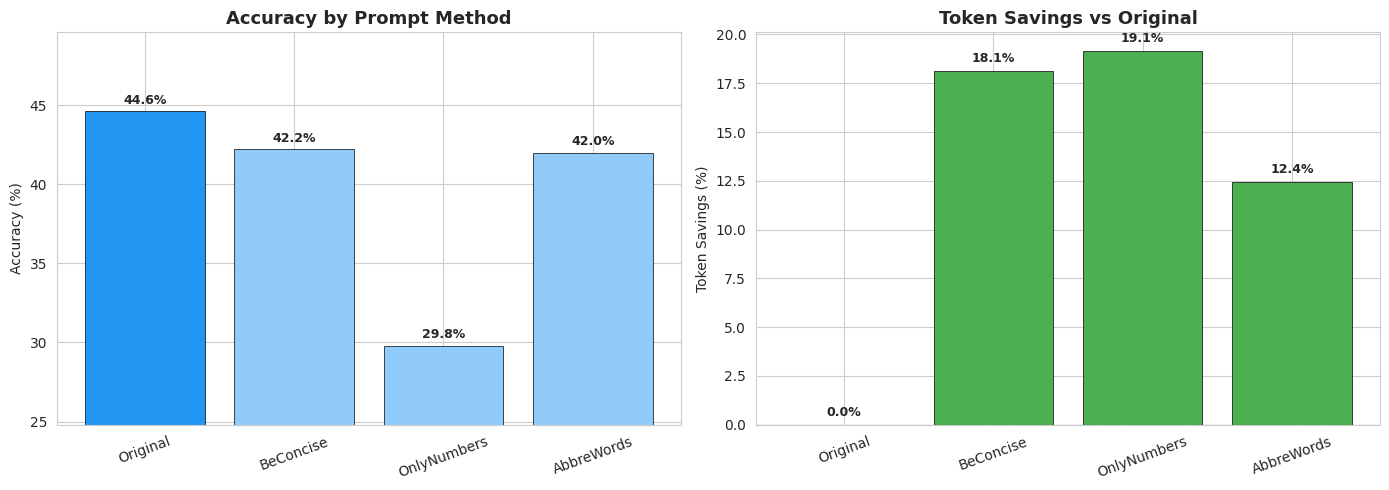

In [13]:
prompt_df = final_df[~final_df['Method'].str.contains("Truncation")].copy()

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2196F3' if m == 'Original' else '#90CAF9' for m in prompt_df['Method']]
bars = axes[0].bar(prompt_df['Method'], prompt_df['Accuracy'],
                    color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title("Accuracy by Prompt Method", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(prompt_df['Accuracy'].min() - 5, prompt_df['Accuracy'].max() + 5)
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, prompt_df['Accuracy']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

colors2 = ['#4CAF50' if s > 0 else '#F44336' for s in prompt_df['Token Savings (%)']]
bars2 = axes[1].bar(prompt_df['Method'], prompt_df['Token Savings (%)'],
                     color=colors2, edgecolor='black', linewidth=0.5)
axes[1].set_title("Token Savings vs Original", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Token Savings (%)")
axes[1].tick_params(axis='x', rotation=20)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
for bar, val in zip(bars2, prompt_df['Token Savings (%)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/prompt_methods.png", dpi=300, bbox_inches='tight')
plt.show()

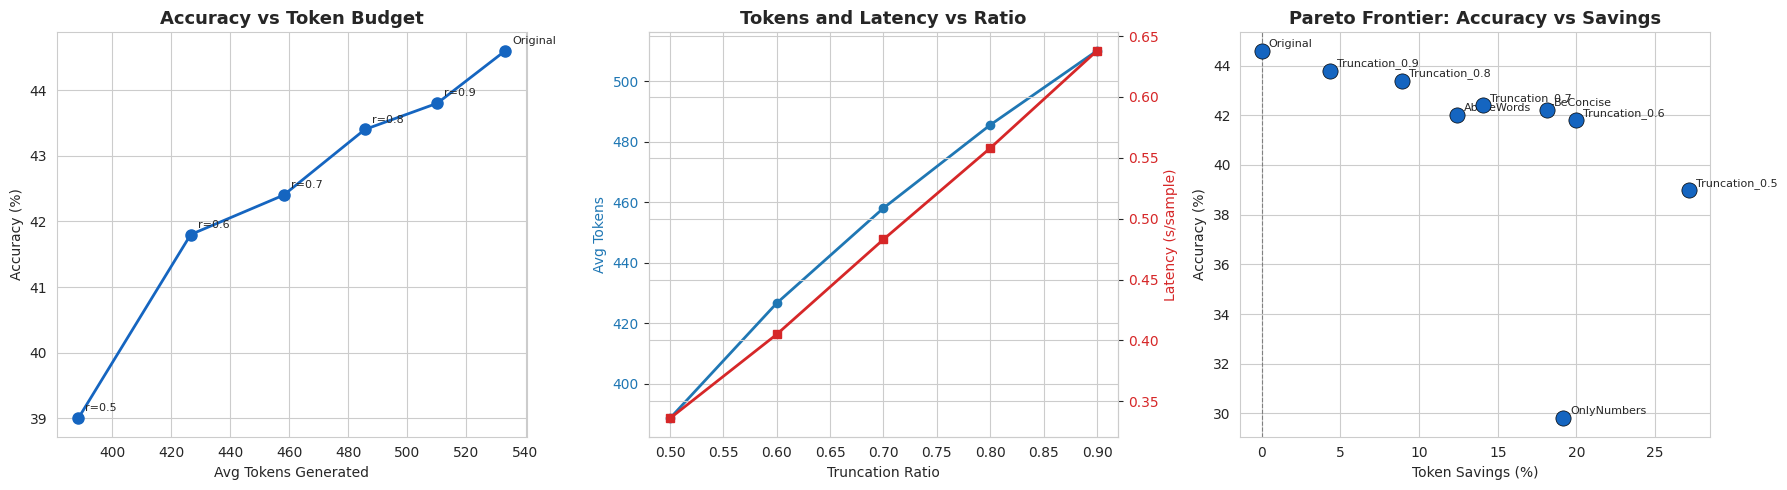

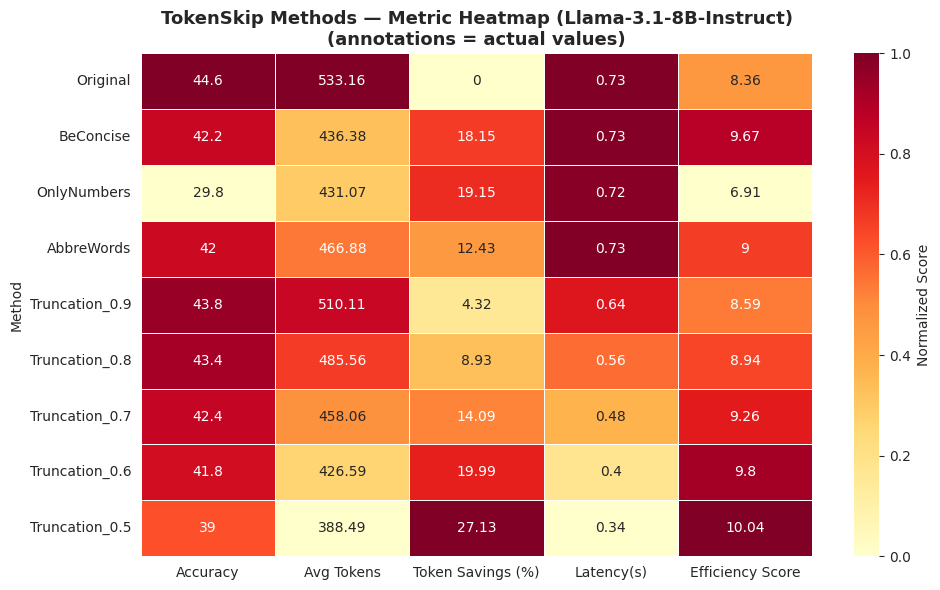

In [14]:
trunc_df = final_df[final_df['Method'].str.contains("Truncation")].copy().sort_values('Ratio')
trunc_with_orig = pd.concat([
    final_df[final_df['Method'] == 'Original'],
    trunc_df
]).sort_values('Avg Tokens')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(trunc_with_orig['Avg Tokens'], trunc_with_orig['Accuracy'],
             'o-', color='#1565C0', linewidth=2, markersize=8)
for _, row in trunc_with_orig.iterrows():
    label = f"r={row['Ratio']}" if pd.notna(row.get('Ratio')) else 'Original'
    axes[0].annotate(label, (row['Avg Tokens'], row['Accuracy']),
                     textcoords="offset points", xytext=(5, 5), fontsize=8)
axes[0].set_xlabel("Avg Tokens Generated")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Accuracy vs Token Budget", fontsize=13, fontweight='bold')

ax1 = axes[1]
ax2 = ax1.twinx()
ax1.plot(trunc_df['Ratio'], trunc_df['Avg Tokens'], 'o-', color='tab:blue', linewidth=2)
ax2.plot(trunc_df['Ratio'], trunc_df['Latency(s)'], 's-', color='tab:red', linewidth=2)
ax1.set_xlabel("Truncation Ratio")
ax1.set_ylabel("Avg Tokens", color='tab:blue')
ax2.set_ylabel("Latency (s/sample)", color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:red')
axes[1].set_title("Tokens and Latency vs Ratio", fontsize=13, fontweight='bold')

axes[2].scatter(final_df['Token Savings (%)'], final_df['Accuracy'],
                s=120, c='#1565C0', zorder=5, edgecolors='black', linewidth=0.5)
for _, row in final_df.iterrows():
    axes[2].annotate(row['Method'], (row['Token Savings (%)'], row['Accuracy']),
                     textcoords="offset points", xytext=(5, 3), fontsize=8)
axes[2].set_xlabel("Token Savings (%)")
axes[2].set_ylabel("Accuracy (%)")
axes[2].set_title("Pareto Frontier: Accuracy vs Savings", fontsize=13, fontweight='bold')
axes[2].axvline(0, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/truncation_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

# Heatmap
pivot = final_df[['Method', 'Accuracy', 'Avg Tokens', 'Token Savings (%)',
                   'Latency(s)', 'Efficiency Score']].set_index('Method')
pivot_norm = (pivot - pivot.min()) / (pivot.max() - pivot.min())

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_norm, annot=pivot.round(2), fmt='g', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Normalized Score'})
ax.set_title("TokenSkip Methods — Metric Heatmap (Llama-3.1-8B-Instruct)\n(annotations = actual values)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/truncation_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

In [15]:
from datasets import load_dataset

ds      = load_dataset("HuggingFaceH4/MATH-500", split="test")
df_meta = ds.to_pandas()
df_meta = df_meta.rename(columns={'problem': 'Question'})[['Question', 'level', 'subject']]

df = df.drop(columns=[c for c in ['level', 'subject', 'Question_norm'] if c in df.columns])

df['Question_norm']      = df['Question'].str.strip().str.replace(r'\s+', ' ', regex=True)
df_meta['Question_norm'] = df_meta['Question'].str.strip().str.replace(r'\s+', ' ', regex=True)

df = df.merge(df_meta[['Question_norm', 'level', 'subject']], on='Question_norm', how='left')
df = df.drop(columns='Question_norm')

print(f"Matched: {df['level'].notna().sum()} / {len(df)}")
print(df[['Question', 'level', 'subject']].head(3))

README.md:   0%|          | 0.00/412 [00:00<?, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating test split:   0%|          | 0/500 [00:00<?, ? examples/s]

Matched: 500 / 500
                                            Question  level  \
0  Convert the point $(0,3)$ in rectangular coord...      2   
1  Define\n\[p = \sum_{k = 1}^\infty \frac{1}{k^2...      5   
2  If $f(x) = \frac{3x-2}{x-2}$, what is the valu...      3   

                subject  
0           Precalculus  
1  Intermediate Algebra  
2               Algebra  


In [16]:
LEVEL_COL   = 'level'
SUBJECT_COL = 'subject'

original_responses = all_responses_dict.get('Original', [])
df['Predicted']    = original_responses
df['Correct']      = [is_correct(p, g) for p, g in zip(original_responses, df['Answer'])]

level_acc = df.groupby(LEVEL_COL)['Correct'].agg(['sum', 'count'])
level_acc['Accuracy'] = (100 * level_acc['sum'] / level_acc['count']).round(2)
print("\nACCURACY BY DIFFICULTY LEVEL")
print(level_acc[['sum', 'count', 'Accuracy']].rename(
    columns={'sum': 'Correct', 'count': 'Total'}).to_string())

type_acc = df.groupby(SUBJECT_COL)['Correct'].agg(['sum', 'count'])
type_acc['Accuracy'] = (100 * type_acc['sum'] / type_acc['count']).round(2)
print("\nACCURACY BY SUBJECT TYPE")
print(type_acc[['sum', 'count', 'Accuracy']].rename(
    columns={'sum': 'Correct', 'count': 'Total'}).to_string())


ACCURACY BY DIFFICULTY LEVEL
       Correct  Total  Accuracy
level                          
1           36     43     83.72
2           58     90     64.44
3           51    105     48.57
4           51    128     39.84
5           27    134     20.15

ACCURACY BY SUBJECT TYPE
                        Correct  Total  Accuracy
subject                                         
Algebra                      82    124     66.13
Counting & Probability       17     38     44.74
Geometry                     14     41     34.15
Intermediate Algebra         19     97     19.59
Number Theory                24     62     38.71
Prealgebra                   53     82     64.63
Precalculus                  14     56     25.00


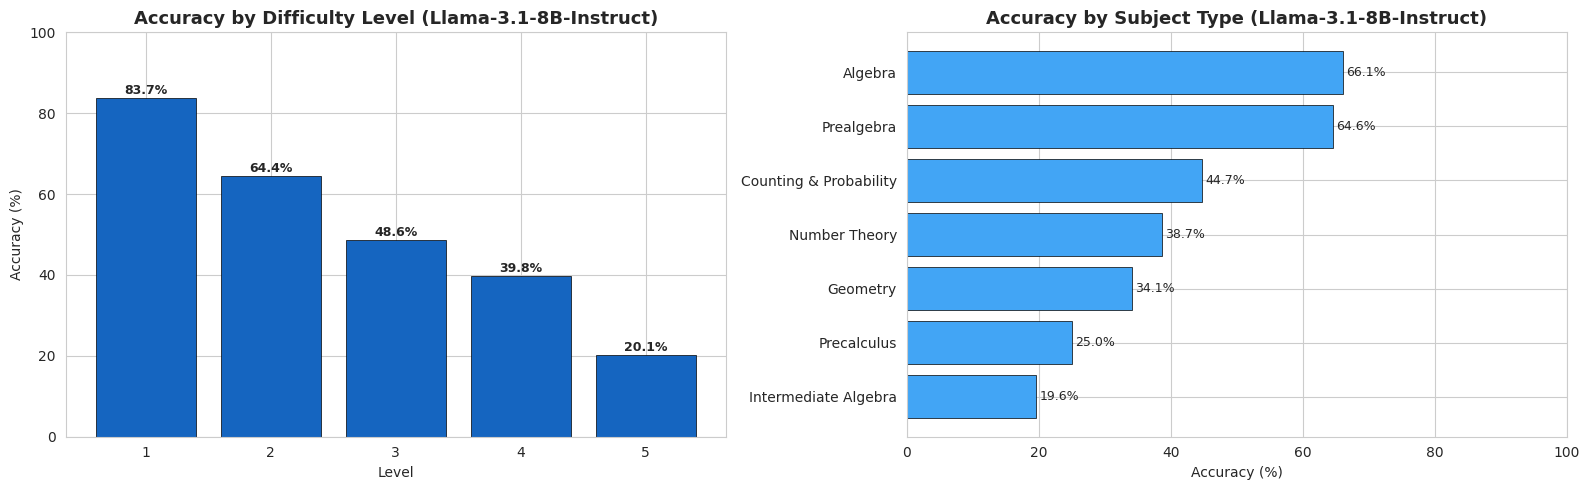

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

level_acc_sorted = level_acc.sort_index()
axes[0].bar(level_acc_sorted.index.astype(str), level_acc_sorted['Accuracy'],
            color='#1565C0', edgecolor='black', linewidth=0.5)
axes[0].set_title("Accuracy by Difficulty Level (Llama-3.1-8B-Instruct)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Level")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(0, 100)
for i, (idx, row) in enumerate(level_acc_sorted.iterrows()):
    axes[0].text(i, row['Accuracy'] + 1, f"{row['Accuracy']:.1f}%",
                 ha='center', fontsize=9, fontweight='bold')

type_acc_sorted = type_acc.sort_values('Accuracy', ascending=True)
axes[1].barh(type_acc_sorted.index, type_acc_sorted['Accuracy'],
             color='#42A5F5', edgecolor='black', linewidth=0.5)
axes[1].set_title("Accuracy by Subject Type (Llama-3.1-8B-Instruct)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Accuracy (%)")
axes[1].set_xlim(0, 100)
for i, (idx, row) in enumerate(type_acc_sorted.iterrows()):
    axes[1].text(row['Accuracy'] + 0.5, i, f"{row['Accuracy']:.1f}%",
                 va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/llama_category_breakdown.png", dpi=300, bbox_inches='tight')

plt.show()

/tmp/ipykernel_106/1252103674.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=token_dist_df, x='Method', y='Tokens', palette='Blues', ax=ax)


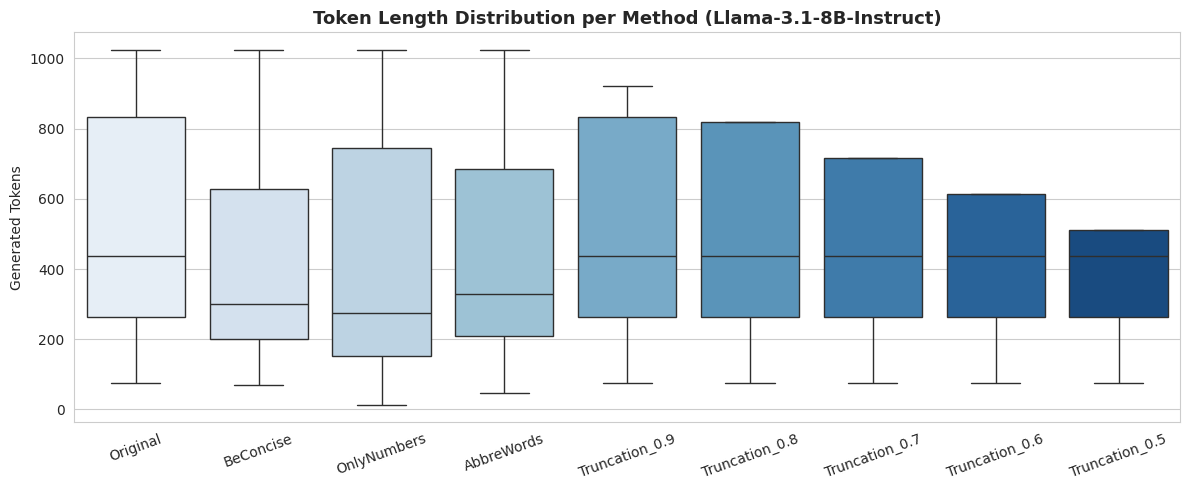

In [18]:
token_dist_data = []
for method, counts in all_token_counts_dict.items():
    for count in counts:
        token_dist_data.append({'Method': method, 'Tokens': count})

token_dist_df = pd.DataFrame(token_dist_data)

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=token_dist_df, x='Method', y='Tokens', palette='Blues', ax=ax)
ax.set_title("Token Length Distribution per Method (Llama-3.1-8B-Instruct)", fontsize=13, fontweight='bold')
ax.set_xlabel("")
ax.set_ylabel("Generated Tokens")
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/llama_token_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

In [19]:
import shutil
shutil.make_archive("/kaggle/working/llama3.1_math500", "zip", OUTPUT_DIR)

'/kaggle/working/llama3.1_math500.zip'